In [9]:
#Exp no. 1 Social Media Engagement Prediction 

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
import numpy as np

data_path = "C:\\Users\\world\\OneDrive\\Desktop\\SJCE-ADS\\Sem-6\\DA-DV-Labs\\socialmediadataset.csv"
df = pd.read_csv(data_path)


categorical_cols = ["Platform", "Hashtags", "Country", "Sentiment"]
numeric_cols = ["Retweets", "Hour", "Month", "Day"]
label_col = "Likes"

X = df[categorical_cols + numeric_cols]
y = df[label_col]

preprocessor = ColumnTransformer([
    ("onehot", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
    ("scale", StandardScaler(), numeric_cols)
])

pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("regressor", LinearRegression())
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Squared Error (RMSE) on test data = {rmse}")

Root Mean Squared Error (RMSE) on test data = 0.6588140470871877


In [12]:
# Exp no. 2 - Statistical Measures and Probability Analysis 

import pandas as pd
import numpy as np
from scipy.stats import pearsonr

# Load the dataset
data_path = "C:\\Users\\world\\OneDrive\\Desktop\\SJCE-ADS\\Sem-6\\DA-DV-Labs\\social_media_events_for_bayes_theorem.csv"

df = pd.read_csv(data_path)

# Display first 5 rows
print(df.head())

# Descriptive statistics for a numerical column
your_column = 'Likes'
print("\nDescriptive Statistics:")
print(f"Mean: {df[your_column].mean():.2f}")
print(f"Standard Deviation: {df[your_column].std():.2f}")
print(f"Max: {df[your_column].max()}")
print(f"Min: {df[your_column].min()}")

# Correlation and Covariance between 'likes' and 'shares'
column1 = 'Likes'
column2 = 'Retweets'
correlation, _ = pearsonr(df[column1], df[column2])
print(f"\nCorrelation between {column1} and {column2}: {correlation:.4f}")
print(f"Covariance between {column1} and {column2}: {df[[column1, column2]].cov().iloc[0, 1]:.2f}")

# Bayes' Theorem: P(Condition | Event) = (P(Event | Condition) * P(Condition)) / P(Event)
p_event = df[df['Event'] == 1].shape[0] / df.shape[0]
p_event_given_condition = df[(df['Event'] == 1) & (df['Condition'] == 1)].shape[0] / df[df['Condition'] == 1].shape[0]
p_condition = df[df['Condition'] == 1].shape[0] / df.shape[0]

p_condition_given_event = (p_event_given_condition * p_condition) / p_event
print(f"\nBayes Theorem Result: P(Condition | Event) = {p_condition_given_event:.4f}")


   PostID  Likes  Retweets  Hour  Event  Condition
0       1     50        10    12      1          1
1       2     30         5    14      0          1
2       3     45         8     9      1          0
3       4     60        12    18      1          1
4       5     25         3    21      0          0

Descriptive Statistics:
Mean: 42.50
Standard Deviation: 16.87
Max: 70
Min: 15

Correlation between Likes and Retweets: 0.9564
Covariance between Likes and Retweets: 84.44

Bayes Theorem Result: P(Condition | Event) = 0.6000


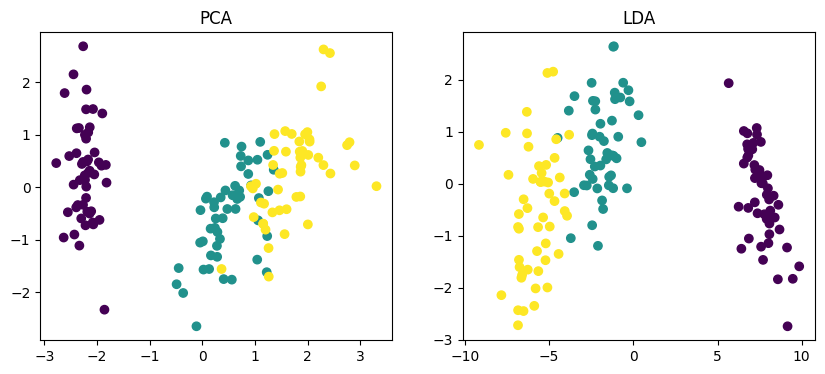

In [13]:
#Exp no. 3 Dimensionality Reduction Methods

import numpy as np
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
X = iris.data
y = iris.target

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.title('PCA')
plt.subplot(1, 2, 2)
plt.scatter(X_lda[:, 0], X_lda[:, 1], c=y, cmap='viridis')
plt.title('LDA')
plt.show()

In [14]:
#Exp no. 4 Regression Techniques

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

data = {
'SquareFeet': [650, 850, np.nan, 1100, 950, 1170, 980, np.nan, 700, 850, 1000, 960, 850],
'Bedrooms': [2, 3, 2, 3, np.nan, 4, 3, 4, 2, 3, 3, 2, 3],
'Age': [5, 7, 3, 10, 2, 12, 8, 4, 5, 6, 9, 11, 7],
'Price': [300000, 350000, 320000, 500000, 330000, 600000, 370000, 620000, 310000,
340000, 400000, 360000, 350000]
}

df = pd.DataFrame(data)

for column in ['SquareFeet', 'Bedrooms', 'Age']:
    df[column].fillna(df[column].median(), inplace=True)

df.drop_duplicates(inplace=True)

scaler = StandardScaler()
df[['SquareFeet', 'Bedrooms', 'Age']] = scaler.fit_transform(df[['SquareFeet', 'Bedrooms',
'Age']])

def detect_outliers_iqr(df, feature):
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    return outliers
    
outliers_squarefeet = detect_outliers_iqr(df, 'SquareFeet')
print("Outliers detected using IQR in 'SquareFeet':\n", outliers_squarefeet)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

X = df[['SquareFeet', 'Bedrooms', 'Age']] 
y = df['Price'] 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)
y_pred = linear_reg.predict(X_test)
print("Linear Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2) 
X_poly = poly.fit_transform(X)

X_train_poly, X_test_poly, y_train, y_test = train_test_split(X_poly, y, test_size=0.2,
random_state=42)
poly_reg = LinearRegression()
poly_reg.fit(X_train_poly, y_train)

y_pred_poly = poly_reg.predict(X_test_poly)
print("Polynomial Regression RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_poly)))

Outliers detected using IQR in 'SquareFeet':
 Empty DataFrame
Columns: [SquareFeet, Bedrooms, Age, Price]
Index: []
Linear Regression RMSE: 53952.69437438348
Polynomial Regression RMSE: 37736.926245272414


Cross-Validation Accuracy (Decision Tree): 0.9533333333333335


C:\Users\world\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


Silhouette Score for K-Means Clustering: 0.45994823920518635


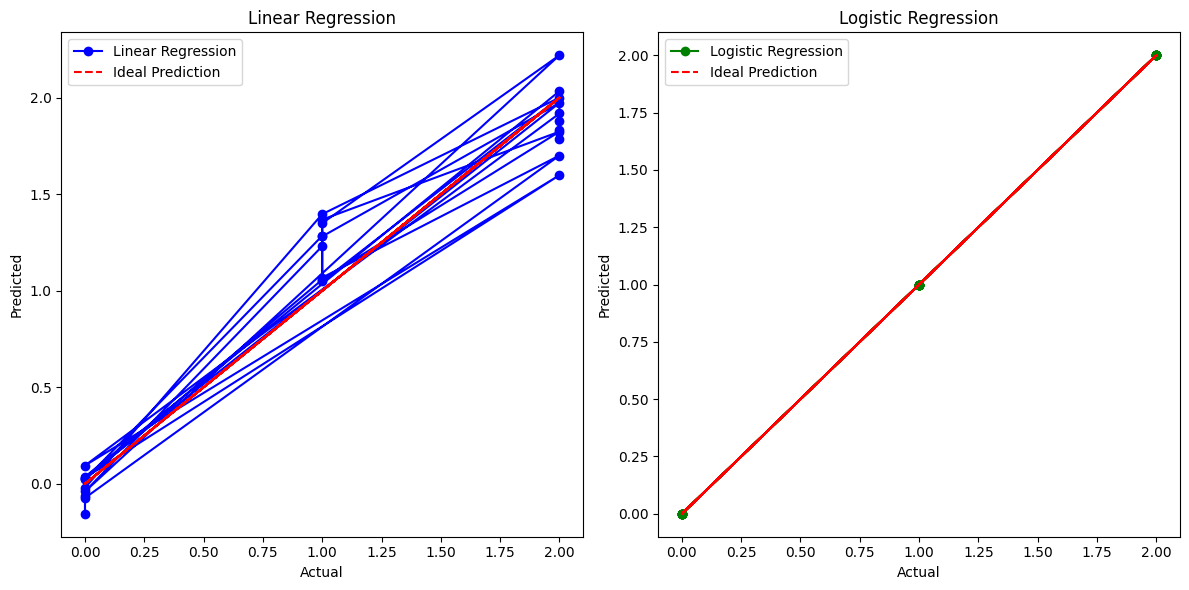

In [15]:
#Exp no. 5 ML Techniques

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train, y_train)

logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

tree_model = DecisionTreeClassifier()
tree_cv_score = cross_val_score(tree_model, X, y, cv=kf)
print ("Cross-Validation Accuracy (Decision Tree):", tree_cv_score.mean())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_model = KMeans(n_clusters=3, random_state=42)
kmeans_model.fit(X_scaled)

silhouette_avg = silhouette_score(X_scaled, kmeans_model.labels_)
print ("Silhouette Score for K-Means Clustering:", silhouette_avg)

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(y_test, linear_reg_model.predict(X_test), 'bo-', label='Linear Regression')
plt.plot(y_test, y_test, 'r--', label='Ideal Prediction')
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(y_test, logreg_model.predict(X_test), 'go-', label='Logistic Regression')
plt.plot(y_test, y_test, 'r--', label='Ideal Prediction')
plt.title("Logistic Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
#Exp no. 7 Word Count using MapReduce

from collections import defaultdict
from concurrent.futures import ThreadPoolExecutor

def mapper(text):
    words = text.split()
    word_count = defaultdict(int)
    for word in words:
        word_count[word] += 1
    return word_count.items()

def reducer(item):
    word, counts = item
    return word, sum(counts)
    
def map_reduce(data):
    with ThreadPoolExecutor() as executor:
        mapped_data = list(executor.map(mapper, data))

    reduced_data = defaultdict(int)
    for sublist in mapped_data:
        for item in sublist:
            word, count = item
            reduced_data[word] += count
    return reduced_data

if __name__ == "__main__":
    data = ["hello world", "world hello", "hello hello world"]
    result = map_reduce(data)
    print(result)

defaultdict(<class 'int'>, {'hello': 4, 'world': 3})


In [31]:
#Exp no. 8 Matrix Multiplication using MapReduce


from collections import defaultdict
A = {(0, 0): 1, (0, 1): 2, (1, 0): 3, (1, 1): 4}
B = {(0, 0): 5, (0, 1): 6, (1, 0): 7, (1, 1): 8}

def map_reduce_multiply(A, B, size=2):
    intermediate = defaultdict(list)

    # Unified Map phase
    for (i, k), v in A.items():
        for j in range(size):
            intermediate[(i, j)].append(('A', k, v))
    for (k, j), v in B.items():
        for i in range(size):
            intermediate[(i, j)].append(('B', k, v))

    # Reduce phase
    result = {
        key: sum(av * bv for _, ak, av in vals for __, bk, bv in vals if ak == bk and _ == 'A' and __ == 'B')
        for key, vals in intermediate.items()
    }
    return result

print(map_reduce_multiply(A, B))

{(0, 0): 19, (0, 1): 22, (1, 0): 43, (1, 1): 50}


In [ ]:
#Exp no. 11 - Codebase for Social Media Visualization

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tweepy

df = pd.read_csv('extracted_tweets.csv', nrows=1000)
print(f'Data loaded: {df.shape[0]} rows, {df.shape[1]} columns')

# --- Simplified Column Distribution ---
def plot_distributions(df, max_cols=6):
    cols = [col for col in df.columns if df[col].nunique() < 50 and df[col].nunique() > 1]
    df = df[cols]
    df.hist(figsize=(15, 8), bins=20, edgecolor='black')
    plt.tight_layout()
    plt.show()

# --- Correlation Heatmap ---
def plot_correlation(df):
    numeric_df = df.select_dtypes(include=[np.number]).dropna(axis=1)
    if numeric_df.shape[1] < 2:
        print("Not enough numeric columns for correlation.")
        return
    plt.figure(figsize=(8, 6))
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()

# --- Scatter Matrix ---
def plot_scatter_matrix(df):
    numeric_df = df.select_dtypes(include=[np.number]).dropna(axis=1)
    if numeric_df.shape[1] > 5:
        numeric_df = numeric_df.iloc[:, :5]  # limit to 5 columns
    pd.plotting.scatter_matrix(numeric_df, figsize=(10, 10), diagonal='kde', alpha=0.7)
    plt.suptitle("Scatter Matrix")
    plt.show()

# --- Twitter API Setup ---
consumer_key = "your-generated-key"
consumer_secret = "your-generated-secret"
access_key = "your-developer-key"
access_secret = "your-developer-secret"

def get_tweets(username, count=10):
    auth = tweepy.OAuthHandler(consumer_key, consumer_secret)
    auth.set_access_token(access_key, access_secret)
    api = tweepy.API(auth)
    tweets = api.user_timeline(screen_name=username, count=count, tweet_mode='extended')
    for tweet in tweets:
        print(f"- {tweet.full_text[:100]}...\n")

# --- Run Visualizations and Twitter Fetch ---
if __name__ == '__main__':
    plot_distributions(df)
    plot_correlation(df)
    plot_scatter_matrix(df)
    get_tweets("your-twitter-handle")
